# Session-Scale Drift — is the inventory-lean calibration stable over time?

`session_scale` depends on volatility, spread, and price — all of which drift. This notebook computes a **daily** scale per name from the feature store and overlays a **30-day trailing average**, for all 38 shortlist names, to see whether each name's calibration is roughly constant or evolving.

**Charts are sorted by the drift from Oct 2025 to Jun 2026** (June mean minus October mean, signed — biggest risers first, biggest fallers last). A summary table of both months' values and the difference is shown first.

### Important methodology note
The daily scale here uses the feature store's **`realized_vol_bps`** (a pre-computed daily vol), NOT the live EMA sigma that `calibrate_all_scales.py` replays. That makes this notebook **fast** (DuckDB, seconds) and correct for the *drift shape*, but the absolute values are a close proxy — a few percent off the calibrated point values. **Use the calibrated CSV for trading; use this notebook only to judge whether that value is stable.** Run All.

In [1]:
# ---- imports + config ----
# fast in-place parquet queries
import duckdb
# frames
import pandas as pd
# numeric
import numpy as np
# plotting inline
import matplotlib.pyplot as plt
%matplotlib inline
# paths
from pathlib import Path

# feature-store root (per-name daily parquet)
FS_ROOT = '/Users/shazzak/Capital Stake - Results/feature_store'
# the shortlist (symbol + tier)
WATCHLIST = '/Users/shazzak/Capital Stake - Results/mm_watchlist_final.csv'

# ---- the calibration constants (must match calibrate_all_scales.py) ----
# risk aversion
GAMMA = 0.15
# inventory in lots at the cap (max_inv/size = 500/50)
POS_LOTS_MAX = 10.0
# worst-case horizon (the open)
TAU = 1.0
# trailing window for the smoothed line (trading days)
TRAIL = 30

# the shortlist names + their tier
wl = pd.read_csv(WATCHLIST)[['tier','symbol']]
SYMBOLS = wl['symbol'].tolist()
TIER = dict(zip(wl['symbol'], wl['tier']))
print(f'{len(SYMBOLS)} names')

38 names


In [2]:
# ---- compute the DAILY session_scale per name, from the feature store ----
# For each name: per DAY, take the median mid, median spread_bps, median
# realized_vol_bps, then apply the exact calibration formula:
#   med_spread_pkr = spread_bps * mid / 1e4
#   sigma_p        = (realized_vol_bps/1e4) * mid      # PKR price vol
#   scale          = med_spread_pkr / (GAMMA * sigma_p^2 * TAU * POS_LOTS_MAX)
# DuckDB reads all of a name's day-files in one query -> fast.

# collected per-name daily frames
daily = {}
# walk names
for sym in SYMBOLS:
    # this name's feature files (both flat and Hive layouts)
    glob = f"{FS_ROOT}/{sym}/date=*.parquet"
    # per-day medians of the three inputs; 'date' parsed from the file path
    q = f"""
        SELECT regexp_extract(filename, 'date=([0-9-]+)', 1) AS d,
               median(mid)             AS mid,
               median(spread_bps)      AS spread_bps,
               median(realized_vol_bps) AS rv_bps
        FROM read_parquet('{glob}', filename=true)
        WHERE mid > 0 AND spread_bps > 0 AND realized_vol_bps > 0
        GROUP BY d ORDER BY d
    """
    try:
        t = duckdb.sql(q).df()
    except Exception as e:
        # name unreadable -> skip, note it
        print(f'  {sym}: skipped ({e})')
        continue
    # drop days with no usable rows
    t = t[t['d'] != '']
    # PKR spread
    t['med_spread_pkr'] = t['spread_bps'] * t['mid'] / 1e4
    # PKR price vol
    t['sigma_p'] = (t['rv_bps'] / 1e4) * t['mid']
    # the daily scale (guard against zero vol)
    t['scale'] = t['med_spread_pkr'] / (GAMMA * t['sigma_p']**2 * TAU * POS_LOTS_MAX)
    # real datetime for plotting
    t['date'] = pd.to_datetime(t['d'])
    # trailing 30-day average of the daily scale
    t = t.sort_values('date')
    t['scale_trail'] = t['scale'].rolling(TRAIL, min_periods=TRAIL//2).mean()
    # store
    daily[sym] = t[['date','scale','scale_trail']].reset_index(drop=True)
print(f'computed daily scales for {len(daily)} names')

computed daily scales for 38 names


In [3]:
# ---- Oct 2025 vs Jun 2026 monthly means + drift, per name ----
# rows collected here
recs = []
# per name
for sym, t in daily.items():
    # October 2025 daily scales
    oct_v = t[(t.date >= '2025-10-01') & (t.date < '2025-11-01')]['scale']
    # June 2026 daily scales
    jun_v = t[(t.date >= '2026-06-01') & (t.date < '2026-07-01')]['scale']
    # means (NaN if a month has no data)
    oct_m = oct_v.mean() if len(oct_v) else np.nan
    jun_m = jun_v.mean() if len(jun_v) else np.nan
    # signed drift (June minus October)
    recs.append({'tier': TIER.get(sym,'?'), 'symbol': sym,
                 'oct_2025': oct_m, 'jun_2026': jun_m,
                 'drift_jun_minus_oct': jun_m - oct_m,
                 'drift_pct': (100*(jun_m-oct_m)/oct_m if oct_m and not np.isnan(oct_m) else np.nan)})
# assemble, sort by signed drift (biggest risers first)
drift = pd.DataFrame(recs).sort_values('drift_jun_minus_oct', ascending=False)
# the ordered symbol list drives the chart order below
CHART_ORDER = drift['symbol'].tolist()
# show the table
print('Session-scale drift Oct 2025 -> Jun 2026 (sorted, biggest riser first):')
drift.style.format({'oct_2025':'{:.2f}','jun_2026':'{:.2f}',
                    'drift_jun_minus_oct':'{:+.2f}','drift_pct':'{:+.0f}%'})

Session-scale drift Oct 2025 -> Jun 2026 (sorted, biggest riser first):


,tier,symbol,oct_2025,jun_2026,drift_jun_minus_oct,drift_pct
4,A_fat_edge,PACE,36.46,87.22,+50.76,+139%
2,A_fat_edge,BAFL,18.35,55.02,+36.67,+200%
10,B_volume,BOP,40.99,73.77,+32.78,+80%
6,A_fat_edge,PIAHCLA,38.78,66.91,+28.13,+73%
32,B_volume,PAEL,27.67,52.79,+25.13,+91%
0,A_fat_edge,FNEL,50.43,69.10,+18.67,+37%
33,B_volume,SEARL,13.60,28.52,+14.92,+110%
24,B_volume,DGKC,12.53,23.15,+10.61,+85%
34,B_volume,THCCL,10.34,20.92,+10.58,+102%
37,B_volume,TOMCL,21.39,31.44,+10.05,+47%


## Per-name charts — daily (faint) + 30-day trailing (bold), same y-axis

Ordered by drift (biggest riser at top). A roughly flat trailing line = stable calibration (the pooled value is fine). A trailing line that climbs or falls materially = the name's calibration is regime-dependent and worth a second look. The faint daily line shows the day-to-day noise the trailing average smooths.

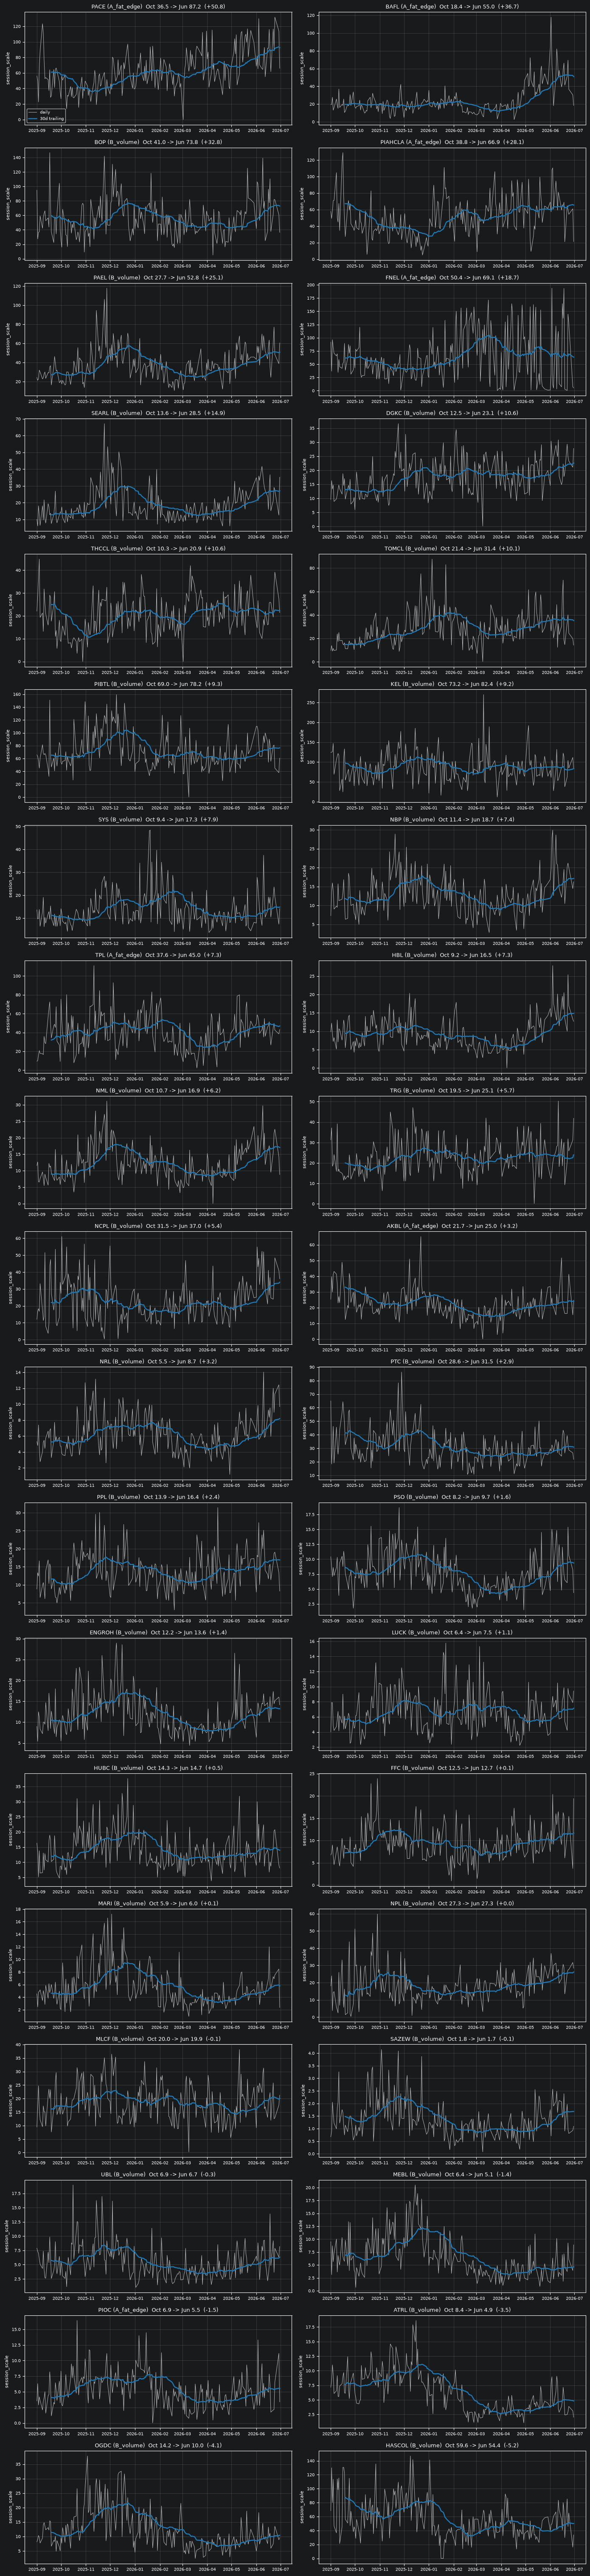

In [4]:
# ---- one chart per name, in drift order ----
# grid: 2 columns, enough rows for all names
ncol = 2
nrow = int(np.ceil(len(CHART_ORDER) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(14, 3.2*nrow))
# flatten for easy indexing
axes = np.array(axes).reshape(-1)
# plot each name
for i, sym in enumerate(CHART_ORDER):
    ax = axes[i]
    t = daily[sym]
    # daily scale: faint
    ax.plot(t['date'], t['scale'], color='#bbbbbb', lw=0.7, label='daily')
    # 30-day trailing: bold
    ax.plot(t['date'], t['scale_trail'], color='#1f77b4', lw=1.8, label='30d trailing')
    # this name's drift for the title
    dr = drift[drift.symbol==sym].iloc[0]
    ax.set_title(f"{sym} ({dr['tier']})  Oct {dr['oct_2025']:.1f} -> Jun {dr['jun_2026']:.1f}  "
                 f"({dr['drift_jun_minus_oct']:+.1f})", fontsize=9)
    ax.set_ylabel('session_scale', fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)
    # legend only on the first chart (saves space)
    if i == 0:
        ax.legend(fontsize=7)
# hide any unused panels
for j in range(len(CHART_ORDER), len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

### How to read this

- **Tight, flat trailing line** → the single calibrated `session_scale` is fine; drift is immaterial. Expect this for the liquid, stable names.
- **Trailing line drifting up/down** → the calibration is regime-dependent. A rising scale usually means volatility *fell* (denominator shrank); a falling scale means volatility rose. Modest drift is tolerable (the strategy is insensitive to the scale within ~2x); large drift is a flag.
- **Very noisy / jumpy trailing line** → the name's microstructure is unstable, which is itself a caution about market-making it, separate from the calibration question.

*Reminder: absolute values use the feature-store daily vol proxy, so they run a few percent off the calibrated point values. The **shape** is what to trust here; the trading scale stays the one from `calibrate_all_scales.py`.*